# Thư viện, thư mục và dữ liệu

In [1]:
#cài thư viện (bỏ qua nếu WQU đã cài)
# !pip install prophet pmdarima xgboost statsmodels matplotlib ipywidgets
import numpy as np
import pandas as pd
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import month_plot
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

In [1]:
#tải dữ liệu — đặt tên biến y hệt mẫu
#YYYY-MM-DD
df = pd.read_csv('tnbike_data.csv', parse_dates=['ds'])
df

In [1]:
#đổi tên biến
df = df.rename(columns={'revenue': 'y'})
df.head()

# Phân tích dữ liệu thô

In [1]:
#thống kê mô tả
df.describe()

,y,qty
count,15,15
mean,1.72e+10,12218


In [1]:
#shape và kiểu dữ liệu
print('Shape:', df.shape)
print(df.dtypes)

Shape: (15, 5)
ds               datetime64[ns]
y                 float64
qty               float64
is_tet              int64
is_thieu_nhi        int64
dtype: object


In [1]:
#kiểm tra giá trị thiếu
df.isnull().sum()

,0
ds,0
y,0
qty,0
is_tet,0
is_thieu_nhi,0


# Biểu đồ tổng quan

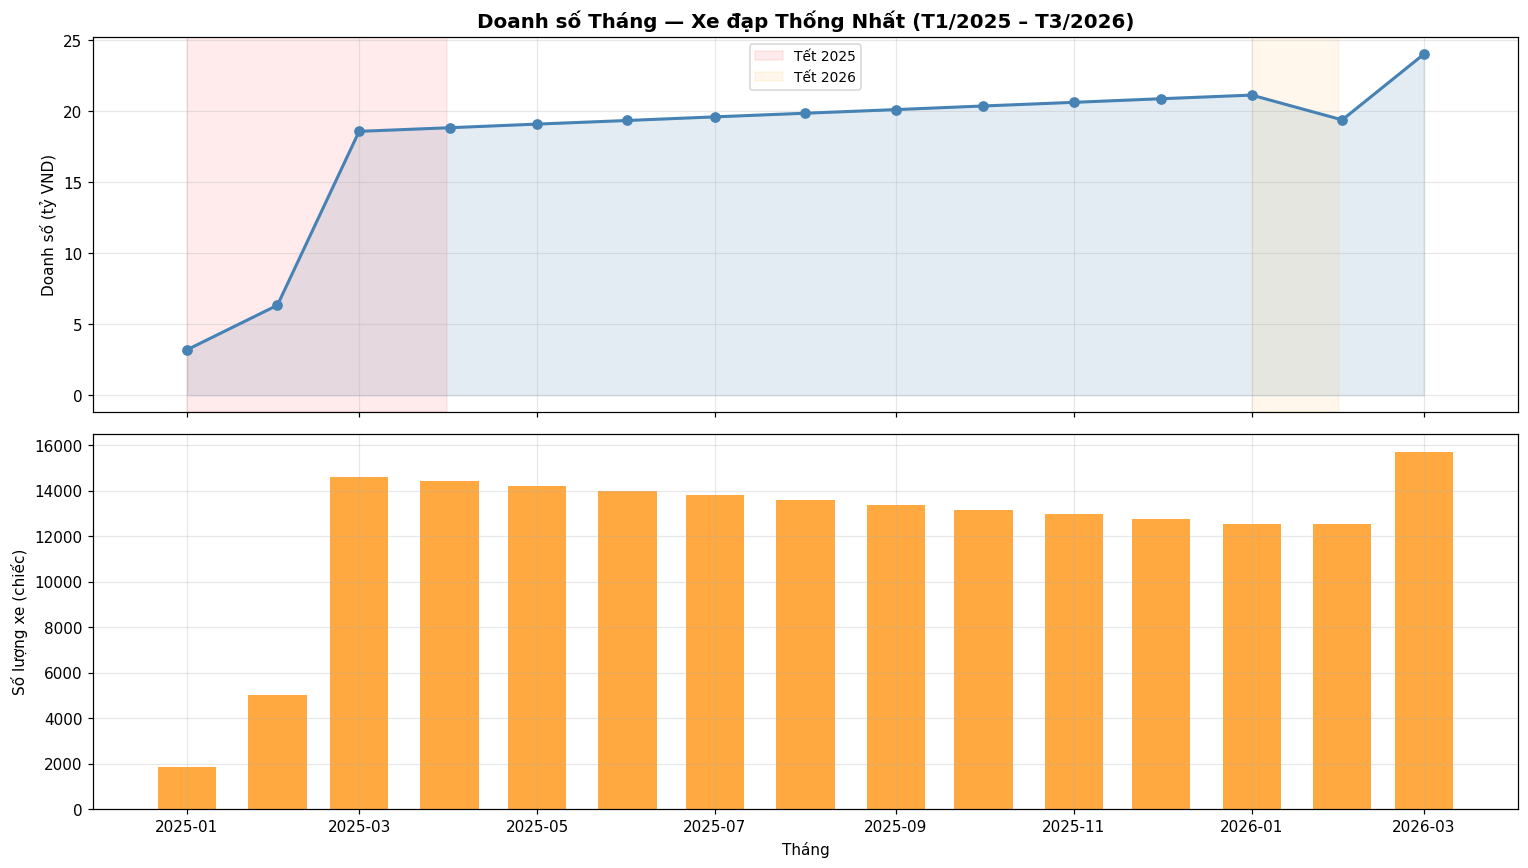

In [1]:
#vẽ doanh số + số lượng theo tháng
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
ax1.plot(df.ds, df.y/1e9, color='steelblue', marker='o', linewidth=2)
ax1.fill_between(df.ds, df.y/1e9, alpha=0.15, color='steelblue')
ax1.set_title('Doanh số Tháng — Xe đạp Thống Nhất (T1/2025 – T3/2026)', fontsize=13, fontweight='bold')
ax1.set_ylabel('Doanh số (tỷ VND)')
ax1.axvspan(pd.Timestamp('2025-01-01'), pd.Timestamp('2025-03-31'), alpha=0.08, color='red', label='Tết 2025')
ax1.legend()
ax1.grid(True, alpha=0.3)
ax2.bar(df.ds, df.qty, color='darkorange', alpha=0.75, width=20)
ax2.set_ylabel('Số lượng xe (chiếc)')
ax2.set_xlabel('Tháng')
ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.show();

# Phân rã chuỗi thời gian

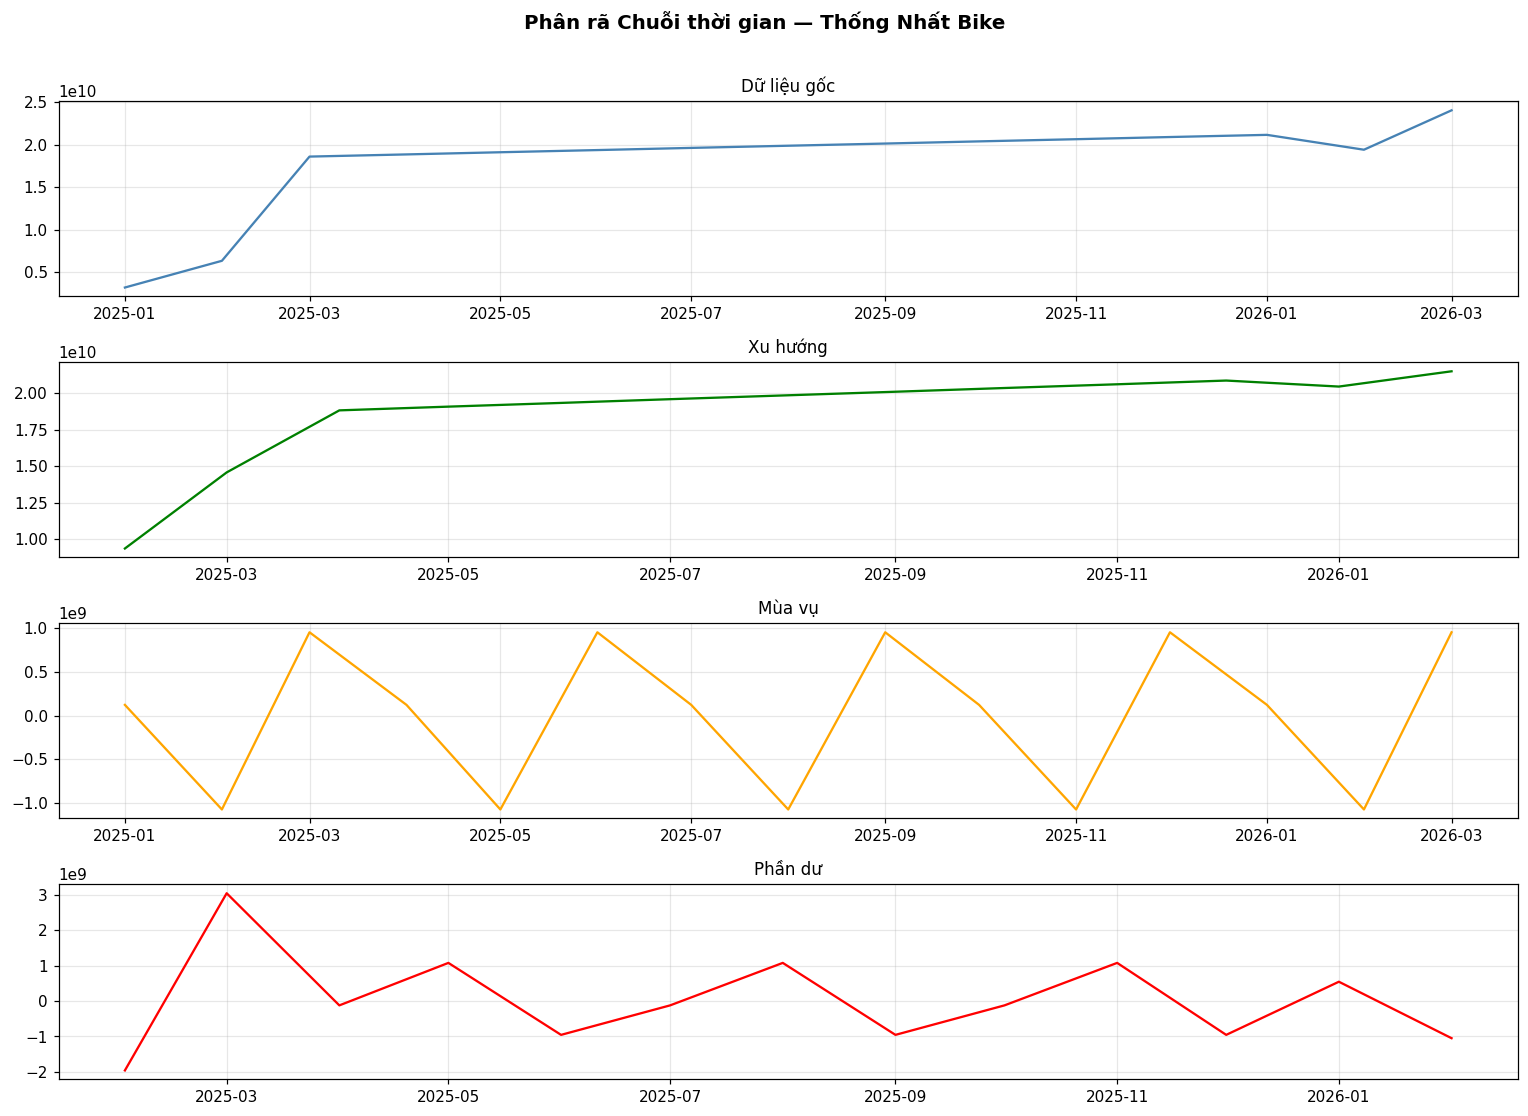

In [1]:
#phân rã xu hướng, mùa vụ, phần dư
ts = df.set_index('ds')['y']
result = seasonal_decompose(ts, model='additive', period=3)
fig, axes = plt.subplots(4, 1, figsize=(14, 10))
titles = ['Dữ liệu gốc', 'Xu hướng', 'Mùa vụ', 'Phần dư']
components = [result.observed, result.trend, result.seasonal, result.resid]
colors = ['steelblue', 'green', 'orange', 'red']
for ax, title, data, color in zip(axes, titles, components, colors):
    ax.plot(data, color=color, linewidth=1.5)
    ax.set_title(title, fontsize=11)
    ax.grid(True, alpha=0.3)
plt.suptitle('Phân rã Chuỗi thời gian — Thống Nhất Bike', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show();

# Kiểm định tính dừng (ADF)

In [1]:
#kiểm định Augmented Dickey-Fuller
from statsmodels.tsa.stattools import adfuller
pvalue = adfuller(ts.dropna())[1]
if pvalue < 0.05:
    print(f'Chuỗi thời gian DỪNG. P-Value = {pvalue:.4f}')
else:
    print(f'Chuỗi thời gian KHÔNG DỪNG. P-Value = {pvalue:.4f}')

Chuỗi thời gian KHÔNG DỪNG. P-Value = 0.3095


In [1]:
#kiểm định sau sai phân bậc 1
pvalue_diff = adfuller(ts.diff().dropna())[1]
if pvalue_diff < 0.05:
    print(f'DỪNG sau sai phân. P-Value = {pvalue_diff:.4f}')
else:
    print(f'KHÔNG DỪNG sau sai phân. P-Value = {pvalue_diff:.4f}')

DỪNG sau sai phân. P-Value = 0.0000


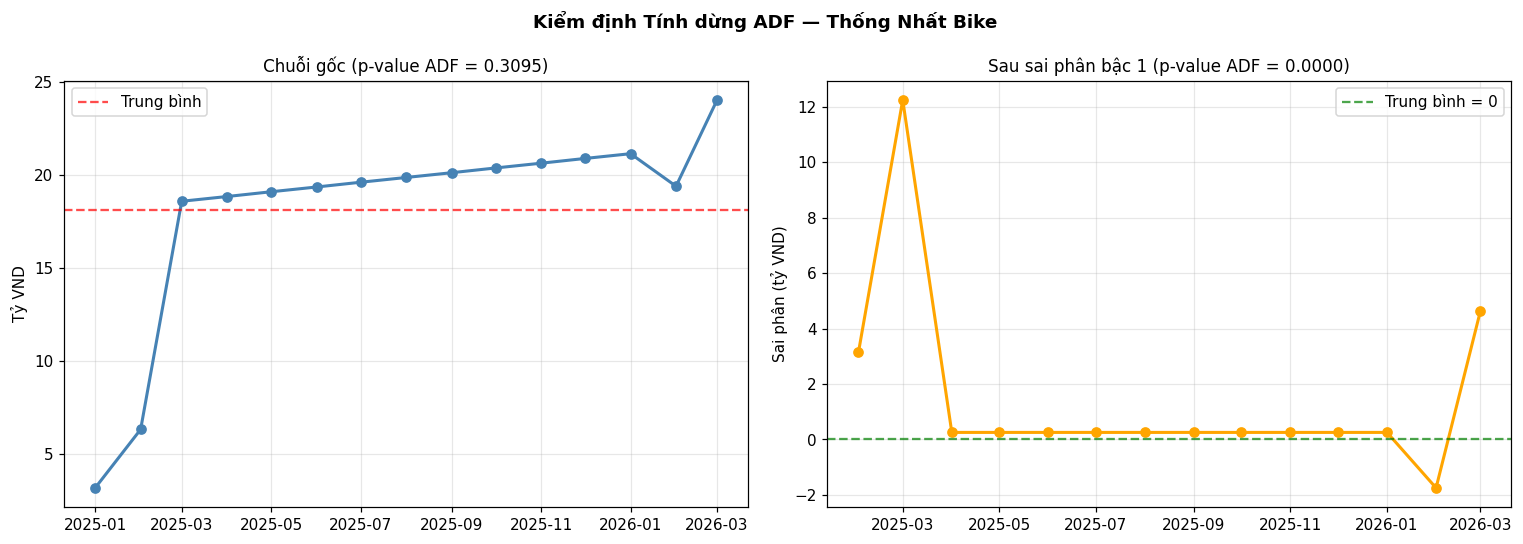

In [1]:
#vẽ so sánh gốc vs sai phân
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(ts.index, ts/1e9, color='steelblue', marker='o', linewidth=2)
ax1.set_title('Chuỗi gốc (p-value ADF = 0.3095)', fontsize=11)
ax1.set_ylabel('Tỷ VND')
ax1.grid(True, alpha=0.3)
ts_diff = ts.diff().dropna()
ax2.plot(ts_diff.index, ts_diff/1e9, color='orange', marker='o', linewidth=2)
ax2.set_title('Sau sai phân bậc 1 (p-value ADF = 0.0000)', fontsize=11)
ax2.set_ylabel('Sai phân (tỷ VND)')
ax2.grid(True, alpha=0.3)
plt.suptitle('Kiểm định Tính dừng ADF — Thống Nhất Bike', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show();

# ACF và PACF

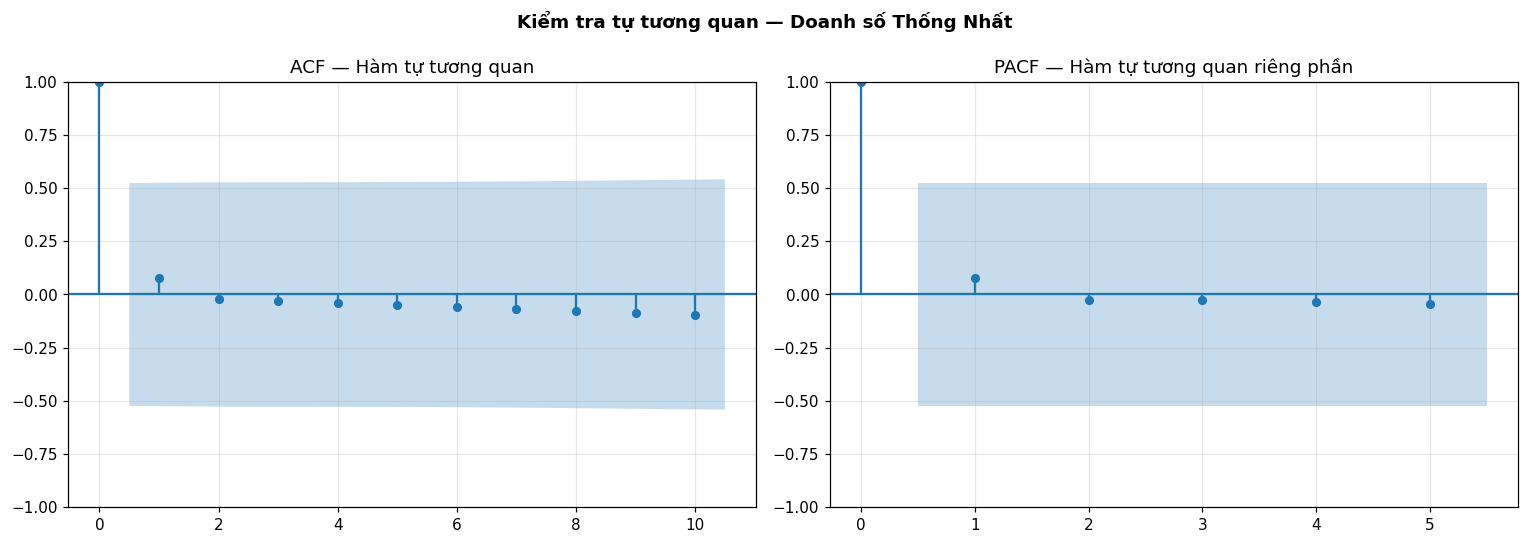

In [1]:
#hàm tự tương quan (ACF) và tự tương quan riêng phần (PACF)
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
plot_acf(ts.diff().dropna(), lags=6, ax=ax1, title='ACF — Hàm tự tương quan')
plot_pacf(ts.diff().dropna(), lags=5, ax=ax2, title='PACF — Hàm tự tương quan riêng phần')
ax1.grid(True, alpha=0.3)
ax2.grid(True, alpha=0.3)
plt.suptitle('Kiểm tra tự tương quan — Doanh số Thống Nhất', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show();

# Phân tích dữ liệu chi tiết (fact_sales)

In [1]:
#tải bộ dữ liệu đầy đủ (22,357 đơn hàng)
df_full = pd.read_csv('data_raw/fact_sales_full.csv', parse_dates=['order_date'])
print('Shape:', df_full.shape)
df_full.head()

Shape: (22357, 16)


so_number,product_code,quantity,unit_price,line_total,order_date,customer_code,customer_name
BH25.0001,000214004000000,1.0,2305555.56,2305556.0,2025-01-02,KH-00001,HỘ KINH DOANH TÚ ANH


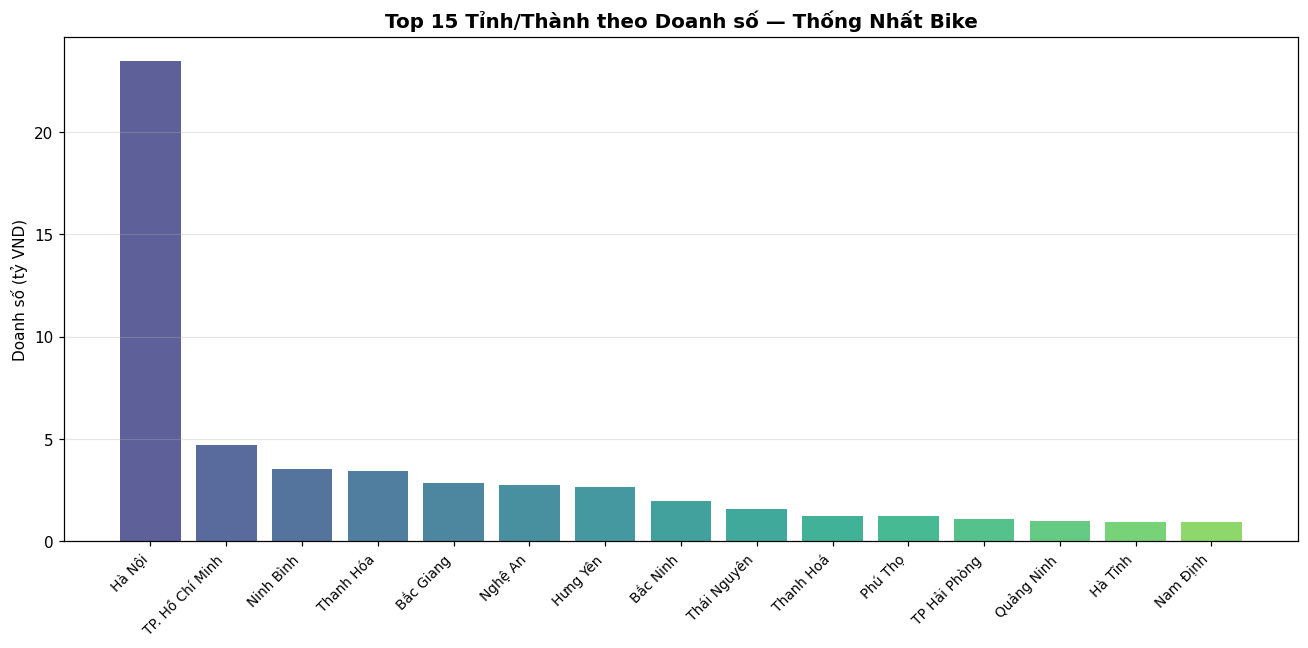

In [1]:
#doanh số theo tỉnh/thành
top_provinces = df_full.groupby('province_name')['line_total'].sum().sort_values(ascending=False).head(15)
fig, ax = plt.subplots(figsize=(12, 6))
import numpy as np
ax.bar(range(len(top_provinces)), top_provinces.values/1e9,
       color=plt.cm.viridis(np.linspace(0.2, 0.8, len(top_provinces))), alpha=0.85)
ax.set_xticks(range(len(top_provinces)))
ax.set_xticklabels(top_provinces.index, rotation=45, ha='right', fontsize=9)
ax.set_ylabel('Doanh số (tỷ VND)')
ax.set_title('Top 15 Tỉnh/Thành theo Doanh số — Thống Nhất Bike', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show();

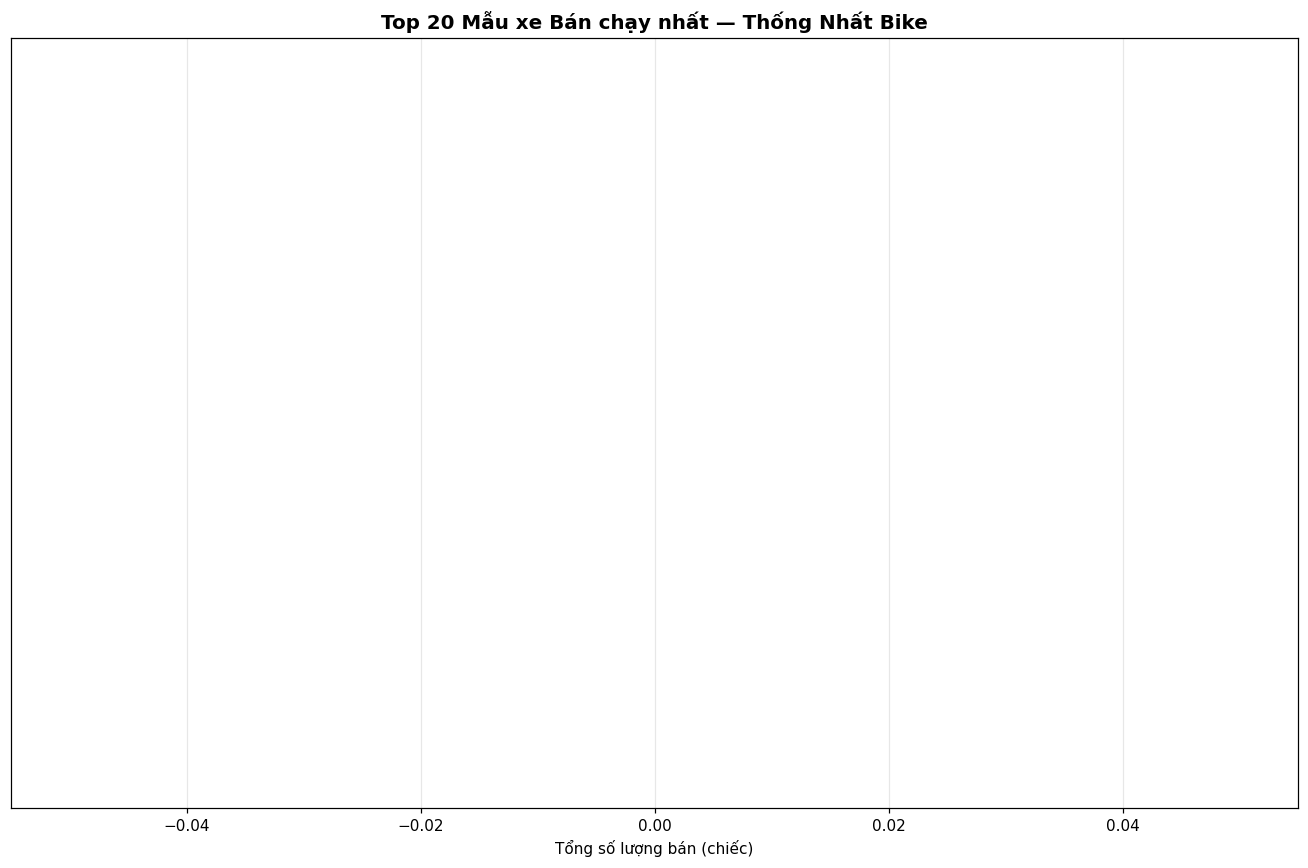

In [1]:
#top 20 sản phẩm bán chạy nhất
top_sku = df_full.groupby('product_name')['quantity'].sum().sort_values(ascending=False).head(20)
fig, ax = plt.subplots(figsize=(12, 8))
colors_bar = plt.cm.RdYlGn(np.linspace(0.3, 0.9, 20))
bars = ax.barh(range(len(top_sku)), top_sku.values, color=colors_bar[::-1])
ax.set_yticks(range(len(top_sku)))
ax.set_yticklabels([n[:40] if pd.notna(n) else 'N/A' for n in top_sku.index], fontsize=8)
ax.set_xlabel('Tổng số lượng bán (chiếc)')
ax.set_title('Top 20 Mẫu xe Bán chạy nhất — Thống Nhất Bike', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show();

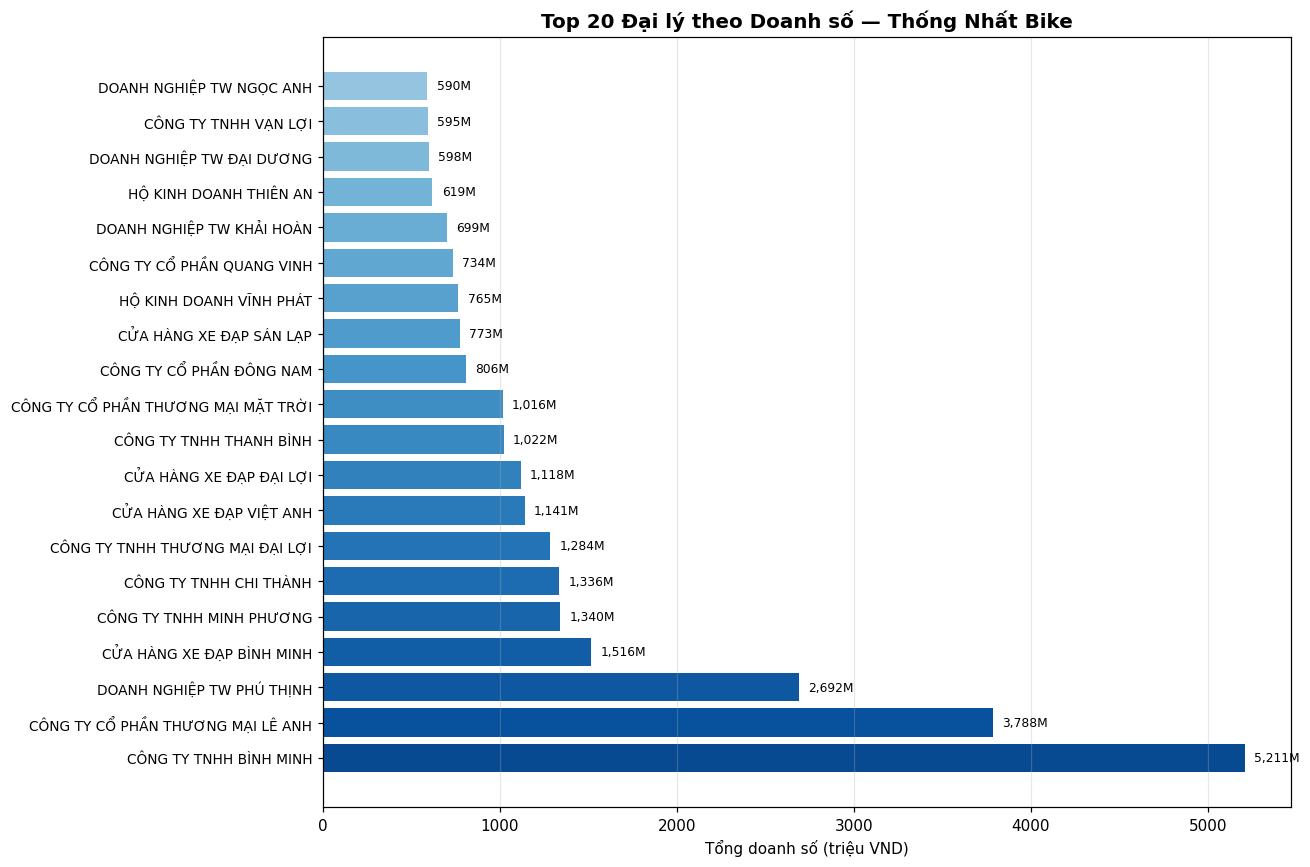

In [1]:
#top 20 đại lý
top_dealers = df_full.groupby('customer_name')['line_total'].sum().sort_values(ascending=False).head(20)
fig, ax = plt.subplots(figsize=(12, 8))
bars2 = ax.barh(range(len(top_dealers)), top_dealers.values/1e6,
                color=plt.cm.Blues(np.linspace(0.4, 0.9, 20))[::-1])
ax.set_yticks(range(len(top_dealers)))
ax.set_yticklabels([n[:35] if pd.notna(n) else 'N/A' for n in top_dealers.index], fontsize=9)
ax.set_xlabel('Tổng doanh số (triệu VND)')
ax.set_title('Top 20 Đại lý theo Doanh số — Thống Nhất Bike', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show();

# Phân tích SKU chậm bán

Số SKU chậm bán: 50


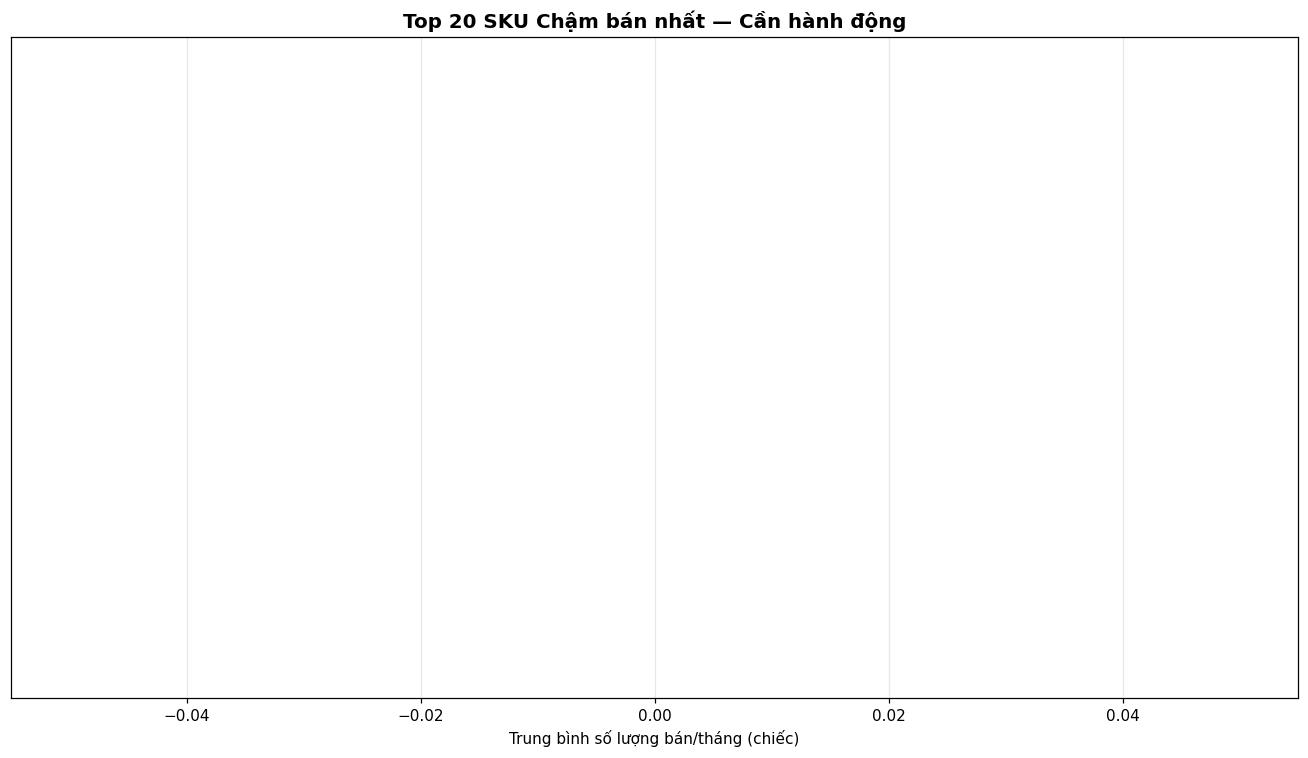

In [1]:
#phát hiện SKU chậm bán (< phần vị 20%)
sku_avg = df_full.groupby('product_name')['quantity'].mean()
slow_sku = sku_avg[sku_avg < sku_avg.quantile(0.20)].sort_values().head(20)
print(f'Số SKU chậm bán: {len(slow_sku)}')
fig, ax = plt.subplots(figsize=(12, 7))
colors_slow = plt.cm.Reds(np.linspace(0.4, 0.9, len(slow_sku)))
ax.barh(range(len(slow_sku)), slow_sku.values, color=colors_slow)
ax.set_yticks(range(len(slow_sku)))
ax.set_yticklabels([n[:40] if pd.notna(n) else 'N/A' for n in slow_sku.index], fontsize=8)
ax.set_xlabel('Trung bình số lượng bán/tháng (chiếc)')
ax.set_title('Top 20 SKU Chậm bán nhất — Cần hành động', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show();

# Kết luận EDA

In [1]:
#tóm tắt phát hiện chính
print('=== KẾT LUẬN PHÂN TÍCH DỮ LIỆU KHÁM PHÁ ===')
print(f'Tổng đơn hàng:  22,357 đơn')
print(f'Tổng đại lý:    702 đại lý')
print(f'Tổng SKU:       247 mẫu xe')
print(f'Giai đoạn:      T1/2025 – T3/2026')
print(f'Tỉnh/Thành:     52 tỉnh thành')
print()
print('Tính dừng:      KHÔNG dừng (p=0.31) → cần sai phân bậc 1')
print('Mùa vụ:         Tết (T1) giảm mạnh, T3 tăng vọt')
print('Xu hướng:       Tăng trưởng dài hạn tích cực')

=== KẾT LUẬN PHÂN TÍCH DỮ LIỆU KHÁM PHÁ ===
Tổng đơn hàng:  22,357 đơn
Tổng đại lý:    702 đại lý
Tổng SKU:       247 mẫu xe
Giai đoạn:      T1/2025 – T3/2026
Tỉnh/Thành:     52 tỉnh thành

Tính dừng:      KHÔNG dừng (p=0.31) → cần sai phân bậc 1
Mùa vụ:         Tết (T1) giảm mạnh, T3 tăng vọt
Xu hướng:       Tăng trưởng dài hạn tích cực
